Setup para os desafios

In [1]:
# ── Importações ──────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Configurações visuais
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


In [2]:
# ── Criação do Dataset ───────────────────────────────
np.random.seed(42)

produtos = {
    "Dom Casmurro":       ("Literatura", 35.90),
    "O Pequeno Príncipe": ("Infantil",   29.90),
    "Sapiens":             ("Ciências",   54.90),
    "Python para Dados":  ("Tecnologia", 89.90),
    "Clean Code":         ("Tecnologia", 95.00),
    "Harry Potter Vol.1": ("Fantasia",   49.90),
    "Atomic Habits":      ("Autoajuda",  44.90),
    "A Arte da Guerra":   ("Filosofia",  32.00),
    "Cosmos":             ("Ciências",   62.50),
    "Cem Anos de Solidão":("Literatura", 39.90),
}

vendedores = ["Ana Lima", "Carlos Mendes", "Bruno Costa", "Fernanda Rocha"]
regioes    = ["Sudeste", "Sul", "Nordeste", "Norte", "Centro-Oeste"]
datas      = pd.date_range("2024-01-01", "2024-06-30", periods=50)

nomes_prod = np.random.choice(list(produtos.keys()), 50)

dados = {
    "id_venda":   range(1, 51),
    "data":       datas.strftime("%Y-%m-%d"),
    "produto":    nomes_prod,
    "categoria":  [produtos[p][0] for p in nomes_prod],
    "quantidade": np.random.randint(1, 6, 50),
    "preco_unit": [produtos[p][1] for p in nomes_prod],
    "vendedor":   np.random.choice(vendedores, 50),
    "regiao":     np.random.choice(regioes, 50),
}

df = pd.DataFrame(dados)
df["total_venda"] = df["quantidade"] * df["preco_unit"]

# Salva como CSV
df.to_csv("vendas_livraria.csv", index=False)

print(f"✅ Dataset criado! Shape: {df.shape}")
print(f"   Colunas: {list(df.columns)}")
df.head()

✅ Dataset criado! Shape: (50, 9)
   Colunas: ['id_venda', 'data', 'produto', 'categoria', 'quantidade', 'preco_unit', 'vendedor', 'regiao', 'total_venda']


,id_venda,data,produto,categoria,quantidade,preco_unit,vendedor,regiao,total_venda
0,1,2024-01-01,Atomic Habits,Autoajuda,3,44.9,Ana Lima,Centro-Oeste,134.7
1,2,2024-01-04,Python para Dados,Tecnologia,1,89.9,Fernanda Rocha,Norte,89.9
2,3,2024-01-08,A Arte da Guerra,Filosofia,4,32.0,Bruno Costa,Centro-Oeste,128.0
3,4,2024-01-12,Clean Code,Tecnologia,2,95.0,Bruno Costa,Nordeste,190.0
4,5,2024-01-15,Atomic Habits,Autoajuda,4,44.9,Carlos Mendes,Nordeste,179.6


In [3]:
# ── Exploração Inicial ───────────────────────────────
df = pd.read_csv("vendas_livraria.csv")

print("═" * 45)
print("📋 INFORMAÇÕES DO DATASET")
print("═" * 45)
print(f"Linhas:   {df.shape[0]}")
print(f"Colunas:  {df.shape[1]}")

print("\n📊 TIPOS DE DADOS:")
print(df.dtypes)

print("\n🔍 VALORES NULOS:")
print(df.isnull().sum())

print("\n📈 ESTATÍSTICAS DESCRITIVAS:")
df[["quantidade", "preco_unit", "total_venda"]].describe().round(2)

═════════════════════════════════════════════
📋 INFORMAÇÕES DO DATASET
═════════════════════════════════════════════
Linhas:   50
Colunas:  9

📊 TIPOS DE DADOS:
id_venda         int64
data               str
produto            str
categoria          str
quantidade       int64
preco_unit     float64
vendedor           str
regiao             str
total_venda    float64
dtype: object

🔍 VALORES NULOS:
id_venda       0
data           0
produto        0
categoria      0
quantidade     0
preco_unit     0
vendedor       0
regiao         0
total_venda    0
dtype: int64

📈 ESTATÍSTICAS DESCRITIVAS:


,quantidade,preco_unit,total_venda
count,50.00,50.00,50.00
mean,2.84,55.57,150.77
std,1.45,23.27,98.01
min,1.00,29.90,29.90
25%,2.00,36.90,79.80
50%,3.00,47.40,128.00
75%,4.00,62.50,190.00
max,5.00,95.00,475.00


In [4]:
# ── Análise de Vendas ────────────────────────────────

# 1. Total faturado
total = df["total_venda"].sum()
print(f"💰 Faturamento Total: R$ {total:,.2f}")

# 2. Faturamento por categoria
print("\n📦 Faturamento por Categoria:")
cat_fat = (df.groupby("categoria")["total_venda"]
             .sum()
             .sort_values(ascending=False))
print(cat_fat.apply(lambda x: f"R$ {x:,.2f}"))

# 3. Melhor vendedor
print("\n🏆 Ranking de Vendedores:")
vend_rank = (df.groupby("vendedor")["total_venda"]
               .sum()
               .sort_values(ascending=False))
print(vend_rank.apply(lambda x: f"R$ {x:,.2f}"))

# 4. Produto mais vendido (em quantidade)
print("\n📚 Top 3 Produtos (qtd vendida):")
top_prod = (df.groupby("produto")["quantidade"]
              .sum()
              .sort_values(ascending=False)
              .head(3))
print(top_prod)

# 5. Venda média por região
print("\n🗺️  Ticket Médio por Região:")
reg_media = (df.groupby("regiao")["total_venda"]
               .mean()
               .sort_values(ascending=False)
               .round(2))
print(reg_media.apply(lambda x: f"R$ {x:,.2f}"))

💰 Faturamento Total: R$ 7,538.40

📦 Faturamento por Categoria:
categoria
Tecnologia    R$ 2,788.80
Autoajuda     R$ 1,122.50
Ciências      R$ 1,071.80
Literatura      R$ 813.90
Filosofia       R$ 704.00
Fantasia        R$ 648.70
Infantil        R$ 388.70
Name: total_venda, dtype: str

🏆 Ranking de Vendedores:
vendedor
Bruno Costa       R$ 3,392.90
Ana Lima          R$ 1,700.80
Fernanda Rocha    R$ 1,361.10
Carlos Mendes     R$ 1,083.60
Name: total_venda, dtype: str

📚 Top 3 Produtos (qtd vendida):
produto
Atomic Habits       25
A Arte da Guerra    22
Clean Code          18
Name: quantidade, dtype: int64

🗺️  Ticket Médio por Região:
regiao
Nordeste        R$ 178.94
Norte           R$ 164.88
Sudeste         R$ 135.95
Centro-Oeste    R$ 135.26
Sul             R$ 133.08
Name: total_venda, dtype: str


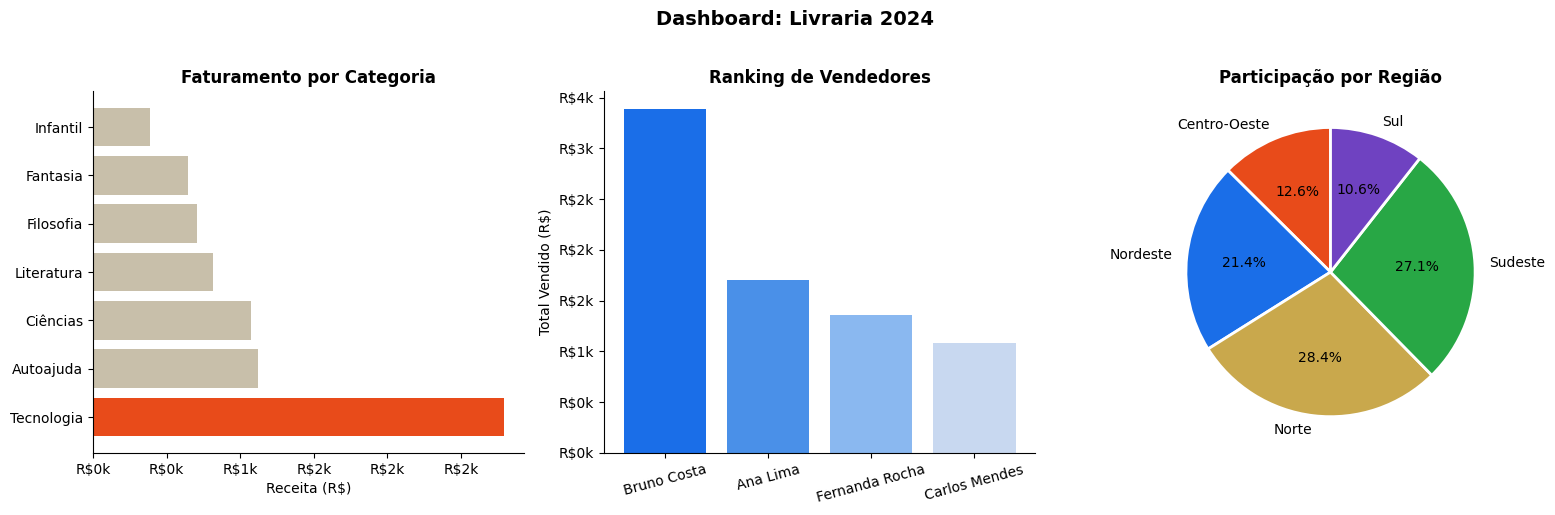

✅ Gráficos salvos em dashboard_livraria.png


In [5]:
# ── Visualizações ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Dashboard: Livraria 2024",
             fontsize=14, fontweight="bold", y=1.02)

# --- Gráfico 1: Faturamento por Categoria (barras) ---
ax1 = axes[0]
cores = ["#e84b1a" if i==0 else "#c8bfaa" for i in range(len(cat_fat))]
ax1.barh(cat_fat.index, cat_fat.values, color=cores)
ax1.set_title("Faturamento por Categoria", fontweight="bold")
ax1.set_xlabel("Receita (R$)")
ax1.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"R${x/1000:.0f}k"))

# --- Gráfico 2: Ranking Vendedores (barras verticais) ---
ax2 = axes[1]
ax2.bar(vend_rank.index, vend_rank.values,
        color=["#1a6ee8","#4a90e8","#8ab8f0","#c8d8f0"])
ax2.set_title("Ranking de Vendedores", fontweight="bold")
ax2.set_ylabel("Total Vendido (R$)")
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda y, _: f"R${y/1000:.0f}k"))
ax2.tick_params(axis="x", rotation=15)

# --- Gráfico 3: Distribuição das Regiões (pizza) ---
ax3 = axes[2]
reg_total = df.groupby("regiao")["total_venda"].sum()
ax3.pie(reg_total, labels=reg_total.index,
        autopct="%1.1f%%",
        colors=["#e84b1a","#1a6ee8","#c9a84c","#28a745","#6f42c1"],
        startangle=90,
        wedgeprops={"edgecolor":"white", "linewidth":2})
ax3.set_title("Participação por Região", fontweight="bold")

plt.tight_layout()
plt.savefig("dashboard_livraria.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráficos salvos em dashboard_livraria.png")

Desafios

In [6]:
#[D1] Calcule a evolução do faturamento mês a mês
# - Dica: converta a coluna "data" com pd.to_datetime() e use .dt.month

df["mes"] = pd.to_datetime(df["data"]).dt.month
fat_mensal = df.groupby("mes")["total_venda"].sum()
print("Faturamento Mensal:\n", fat_mensal.apply(lambda x: f"R$ {x:,.2f}"))

Faturamento Mensal:
 mes
1    R$ 1,251.40
2    R$ 1,281.10
3    R$ 1,505.60
4    R$ 1,284.40
5    R$ 1,263.50
6      R$ 952.40
Name: total_venda, dtype: str


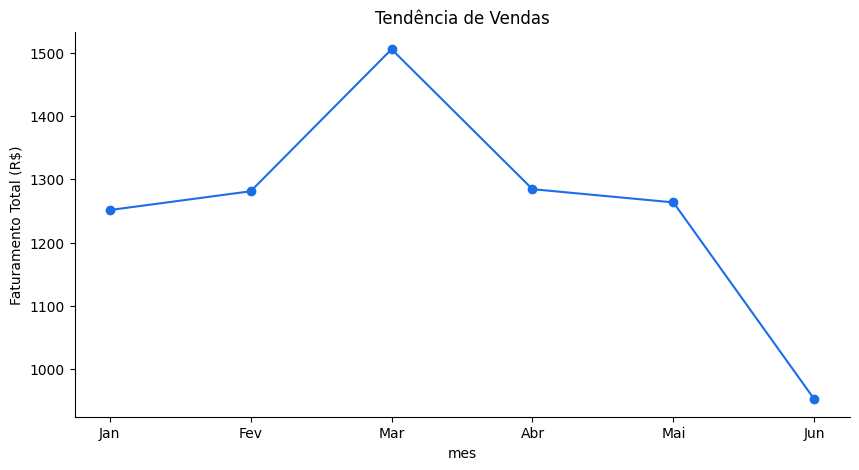

In [7]:
#[D2] Crie um gráfico de linha mostrando a tendência de vendas ao longo do tempo (eixo X: mês, eixo Y: faturamento total)

fat_mensal.plot(kind='line', marker='o', figsize=(10, 5), color='#1a6ee8', title="Tendência de Vendas")
plt.xticks(fat_mensal.index, ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun'])
plt.ylabel("Faturamento Total (R$)")
plt.savefig("tendencia_vendas.png", bbox_inches="tight")
plt.show()

In [8]:
#[D3] Descubra qual vendedor tem o maior ticket médio (não o maior volume, mas a média por venda)

print("\nTicket Médio por Vendedor:\n", df.groupby("vendedor")["total_venda"].mean().sort_values(ascending=False).apply(lambda x: f"R$ {x:,.2f}"))


Ticket Médio por Vendedor:
 vendedor
Bruno Costa       R$ 161.57
Fernanda Rocha    R$ 151.23
Ana Lima          R$ 141.73
Carlos Mendes     R$ 135.45
Name: total_venda, dtype: str


In [9]:
#[D4] Filtre apenas as vendas com total_venda > 200 e analise quais categorias dominam as vendas de alto valor

print("\nCategorias que dominam as vendas > R$ 200:\n", df[df["total_venda"] > 200]["categoria"].value_counts())


Categorias que dominam as vendas > R$ 200:
 categoria
Tecnologia    5
Fantasia      1
Ciências      1
Autoajuda     1
Name: count, dtype: int64


In [10]:
#[D5] Adicione 5 linhas com valores nulos no dataset e escreva código para identificá-los e tratá-los com .fillna() ou .dropna()

linhas_nulas = pd.DataFrame({
    "id_venda":   [51, 52, 53, 54, 55],
    "data":       [np.nan, "2024-07-02", np.nan, "2024-07-04", "2024-07-05"],
    "produto":    [np.nan, "Sapiens", "Cosmos", np.nan, "Clean Code"],
    "categoria":  [np.nan, "Ciências", "Ciências", np.nan, "Tecnologia"],
    "quantidade": [np.nan, 2, np.nan, 1, 3],
    "preco_unit": [np.nan, 54.9, 62.5, np.nan, 95.0],
    "vendedor":   ["Ana Lima", np.nan, "Bruno Costa", np.nan, "Fernanda Rocha"],
    "regiao":     ["Sul", "Sudeste", np.nan, "Norte", np.nan],
    "total_venda":[np.nan, 109.8, np.nan, np.nan, 285.0]
})

df_com_nulos = pd.concat([df, linhas_nulas], ignore_index=True)
print("\nQuantidade de valores nulos por coluna:\n", df_com_nulos.isnull().sum())

df_tratado = df_com_nulos.dropna(subset=['total_venda']).fillna({
    "vendedor": "Não Identificado",
    "quantidade": df_com_nulos["quantidade"].median()
})

print("\nQuantidade de nulos no dataset limpo:\n", df_tratado.isnull().sum())


Quantidade de valores nulos por coluna:
 id_venda       0
data           2
produto        2
categoria      2
quantidade     2
preco_unit     2
vendedor       2
regiao         2
total_venda    3
mes            5
dtype: int64

Quantidade de nulos no dataset limpo:
 id_venda       0
data           0
produto        0
categoria      0
quantidade     0
preco_unit     0
vendedor       0
regiao         1
total_venda    0
mes            2
dtype: int64
